# VirtualiZarr → Icechunk in Cloud Storage

This notebook creates an Icechunk store containing virtual references to NASA PACE OCI Level-3 Kd products for  **in-region AWS S3 access**. 

The code is a bit hairy to deal with the tokens only lasting an hour and the process can take up to 5 hours. Instead of letting it crash the code refreshes the repo every commit which lets you update the token. If the token, gets close to expiring the code stops and waits.

In [1]:
# Required packages
!pip install -qU icechunk  virtualizarr obspec_utils earthaccess

In [1]:
import warnings
import shutil
from pathlib import Path

import xarray as xr
import icechunk
from obstore.store import from_url
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from obspec_utils.registry import ObjectStoreRegistry

warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning,
)

In [2]:
# need v 18
import earthaccess
earthaccess.__version__

'0.18.0'

## Get the results list via earthaccess

earthaccess is going to take care of the authentication pieces for us.

In [3]:
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

## Write store to Source Coop

### Set up the remote file config

In [4]:
# Create an object-store handle for the REMOTE files.
url_prefix = "s3://ob-cumulus-prod-public/"
store = from_url(url_prefix, region="us-west-2", skip_signature=True)
registry = ObjectStoreRegistry({url_prefix: store})
parser = HDFParser()

# Icechunk config
config = icechunk.RepositoryConfig.default()

# Split manifests every 100 time chunks.
config.manifest = icechunk.ManifestConfig(
    splitting=icechunk.ManifestSplittingConfig.from_dict(
        {
            icechunk.ManifestSplitCondition.AnyArray(): {
                icechunk.ManifestSplitDimCondition.DimensionName("time"): 100
            }
        }
    )
)

# Tell the store how to access the remote chunks.
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=url_prefix,
        store=icechunk.s3_store(
            region="us-west-2",
            anonymous=False,
        ),
    )
)

### Set up the Icechunk storage bucket and open Icechunk store

Source Coop makes it easy to get this info via a 'View Credentials' link. Since I am working in a Jupyter notebook, I will load the variables via a json file. 

1. Create a json file and add to `.gitignore` so you do not accidentally commit it to GitHub. Never hard-code tokens into notebooks.
2. Get the bucket info: provider (S3, GCP, etc), bucket, prefix and pass that to set up the storage object.


In [5]:
# Read in the json file
import json
from pathlib import Path

creds_file = "source-creds.json"
with open(creds_file) as f:
    source_creds = json.load(f)
    
# This info you get from your storage
source_bucket = "us-west-2.opendata.source.coop"
source_prefix = "fish-pace/pace-oci/inregion/PACE_OCI_L3M_KD"
source_region = "us-west-2"

storage = icechunk.s3_storage(
    bucket=source_bucket,
    prefix=source_prefix,
    region=source_creds["region_name"],
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

# Create store if it is empty
try:
    repo = icechunk.Repository.create(storage, config)
    print("Created new Icechunk repo")
except Exception:
    repo = icechunk.Repository.open(storage, config=config)
    print("Opened existing Icechunk repo")

Opened existing Icechunk repo


In [6]:
import json
from pathlib import Path
import time
from datetime import datetime, timezone, timedelta

import icechunk
product = "PACE_OCI_L3M_KD"

def _get_source_creds_expiration(
    creds_file,
    assumed_ttl_minutes=60,
):
    """
    Get expiration from the file modification time since json has no expiration
    """

    mtime = datetime.fromtimestamp(
        Path(creds_file).stat().st_mtime,
        tz=timezone.utc,
    )

    expiration = mtime + timedelta(minutes=assumed_ttl_minutes)
    return expiration

def open_source_icechunk_repo(
    creds_file="source-creds.json",
    bucket="us-west-2.opendata.source.coop",
    prefix=f"fish-pace/pace-oci/inregion/{product}",
    config=None,
    min_minutes_left=15,
    assumed_ttl_minutes=60,
    create_if_missing=True,
    verbose=True,
    check_expiration=True,
):
    """
    Open or create an Icechunk repo using Source Cooperative temporary credentials.

    If the creds file has no explicit expiration, estimate expiration from:
        file modification time + assumed_ttl_minutes

    If check_expiration=True, raises RuntimeError if less than min_minutes_left remain.
    """

    creds_file = Path(creds_file)

    with creds_file.open() as f:
        source_creds = json.load(f)

    expiration = _get_source_creds_expiration(
        creds_file=creds_file,
        assumed_ttl_minutes=assumed_ttl_minutes,
    )

    now = datetime.now(timezone.utc)
    time_left = expiration - now

    if check_expiration and time_left < timedelta(minutes=0):
        print(
            f"Stopping cleanly. Source credentials expired. "
            f"Refresh {creds_file} and set start_index."
        )
        return None, None, None, time_left

    region = (
        source_creds.get("region_name")
        or source_creds.get("region")
        or "us-west-2"
    )

    storage = icechunk.s3_storage(
        bucket=bucket,
        prefix=prefix,
        region=region,
        access_key_id=source_creds["aws_access_key_id"],
        secret_access_key=source_creds["aws_secret_access_key"],
        session_token=source_creds["aws_session_token"],
    )

    if create_if_missing:
        try:
            repo = icechunk.Repository.create(storage, config)
            if verbose:
                print("Created new Icechunk repo")
        except Exception:
            repo = icechunk.Repository.open(storage, config=config)
            if verbose:
                print("Opened existing Icechunk repo")
    else:
        repo = icechunk.Repository.open(storage, config=config)
        if verbose:
            print("Opened existing Icechunk repo")

    if verbose:
        print(f"Time remaining on token: {time_left}")

    return repo, storage, source_creds, time_left

## Create function for writing the stores

In [7]:
import time
from pathlib import Path
import pandas as pd
import earthaccess

def pace_start_time_from_filename(filename):
    # PACE_OCI.20240305.L3m.DAY...
    # PACE_OCI.20240305_20240312.L3m.8D...
    # PACE_OCI.20240301_20240331.L3m.MO...
    date_part = filename.split(".")[1]
    start_date = date_part.split("_")[0]

    return (
        pd.to_datetime(start_date, format="%Y%m%d")
        .to_datetime64()
    )

def wait_for_fresh_repo(
    *,
    creds_file="source-creds.json",
    min_minutes_left=15,
    config=config,
    verbose=True,
):
    while True:
        repo, storage, source_creds, time_left = open_source_icechunk_repo(
            creds_file=creds_file,
            create_if_missing=True,
            config=config,
            check_expiration=True,
            verbose=False,
        )

        if time_left >= timedelta(minutes=min_minutes_left):
            if verbose:
                print(f"Token ok. Time remaining: {time_left}")
            return repo, storage, source_creds, time_left

        print(
            f"Source credentials expire in about {time_left}. "
            f"Refresh {creds_file} before continuing."
        )

        try:
            ans = input("Enter y after refreshing token, or n to stop: ").strip().lower()
        except KeyboardInterrupt:
            print("Input interrupted. Stopping cleanly.")
            return None, None, None, time_left

        if ans == "y":
            continue

        if ans == "n":
            print("Stopping. Refresh token and rerun starting at the last run file.")
            return None, None, None, time_left

        print("Please enter y or n.")    
        
def write_results_to_icechunk(
    results,
    *,
    group_base="daily/4km",
    commit_every=10,
    parser="HDFParser",
    start_index=0,
    branch="main",
    config=None, # required!
    creds_file="source-creds.json",
    min_minutes_left=15,
):
    total_added = start_index

    repo, storage, source_creds, time_left = wait_for_fresh_repo(
        creds_file=creds_file,
        min_minutes_left=min_minutes_left,
        config=config,
        verbose=False,
    )

    # token expired
    if repo is None:
        return total_added
    
    session = repo.writable_session(branch)
    start = time.perf_counter()

    for i, res in enumerate(results[start_index:], start=start_index):
        url = res.data_links(in_region=True)[0]
        filename = Path(url).name

        vds = earthaccess.virtualize(
            [res],
            access="direct",
            load=False,
            concat_dim="time",
            coords="all",
            compat="override",
            combine_attrs="drop_conflicts",
            parser=parser,
        )

        file_time = pace_start_time_from_filename(filename)
        vds = vds.assign_coords(time=[file_time])

        if total_added == 0:
            vds.vz.to_icechunk(session.store, group=group_base)
        else:
            vds.vz.to_icechunk(session.store, group=group_base, append_dim="time")

        total_added += 1

        if total_added % commit_every == 0:
            elapsed = time.perf_counter() - start
            snapshot_id = session.commit(f"Add through file {i + 1}")
            print(
                f"Finished file {i + 1} in {elapsed:.2f} seconds. "
                f"snapshot_id: {snapshot_id}. "
            )

            repo, storage, source_creds, time_left = wait_for_fresh_repo(
                creds_file=creds_file,
                min_minutes_left=min_minutes_left,
                verbose=False,
            )
            print(f"    time left on token: {time_left}")

            session = repo.writable_session(branch)
            start = time.perf_counter()

    if total_added % commit_every != 0:
        snapshot_id = session.commit(f"Add through file {total_added}")
        print("Committed:", snapshot_id)

    return total_added

## Write the daily files

### 0p1deg

In [20]:
# Check the urls
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-01-01", "2026-06-30"),
    granule_name="*.DAY.*.V3_2.0p1deg.*"
)
print(len(results))
urls = [res.data_links(in_region=True)[0] for res in results]
urls[0:2]

770


['s3://ob-cumulus-prod-public/PACE_OCI.20240305.L3m.DAY.KD.V3_2.0p1deg.nc',
 's3://ob-cumulus-prod-public/PACE_OCI.20240306.L3m.DAY.KD.V3_2.0p1deg.nc']

In [26]:
%%script false --no-raise
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-01-01", "2026-06-30"),
    granule_name="*.DAY.*.V3_2.0p1deg.*"
)
print(len(results))

write_results_to_icechunk(
    results,
    config=config, # required to be defined above
    group_base="daily/0p1deg",
    commit_every=10,
)

770
Finished file 10 in 21.74 seconds. snapshot_id: 26VNW3BE9171QGABX0ZG. 
    time left on token: 0:45:12.559867
Finished file 20 in 16.37 seconds. snapshot_id: J0YJEE217DW8SYFE9QP0. 
    time left on token: 0:44:55.476293
Finished file 30 in 17.52 seconds. snapshot_id: 5Y52650JYGHE4JSQB1S0. 
    time left on token: 0:44:37.220261
Finished file 40 in 18.75 seconds. snapshot_id: BNNY5GRDQV9C1JNX29EG. 
    time left on token: 0:44:17.566871
Finished file 50 in 19.90 seconds. snapshot_id: W9Z6B3NGADS97MT120XG. 
    time left on token: 0:43:56.895625
Finished file 60 in 19.34 seconds. snapshot_id: Z53KBFTEGNMRVJZ0FJ00. 
    time left on token: 0:43:36.630690
Finished file 70 in 18.92 seconds. snapshot_id: J178D17P5HTEXN5GTGK0. 
    time left on token: 0:43:16.761904
Finished file 80 in 18.24 seconds. snapshot_id: XAAS7PSF1BM6FJD50P5G. 
    time left on token: 0:42:57.455160
Finished file 90 in 16.55 seconds. snapshot_id: 16R57WYHQZKEDW0M2MM0. 
    time left on token: 0:42:39.862408
Finish

770

In [9]:
import json
from pathlib import Path

creds_file = "source-creds.json"
with open(creds_file) as f:
    source_creds = json.load(f)
    
# This info you get from your storage
source_bucket = "us-west-2.opendata.source.coop"
source_prefix = "fish-pace/pace-oci/inregion/PACE_OCI_L3M_KD"
source_region = "us-west-2"

storage = icechunk.s3_storage(
    bucket=source_bucket,
    prefix=source_prefix,
    region=source_creds["region_name"],
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

url_prefix = "s3://ob-cumulus-prod-public/"

repo0 = icechunk.Repository.open(storage)

repo0.config

icechunk.config.RepositoryConfig(
    inline_chunk_threshold_bytes=None,
    get_partial_values_concurrency=None,
    max_concurrent_requests=None,
    num_updates_per_repo_info_file=None,
    compression=None,
    caching=None,
    storage=icechunk.storage.StorageSettings(
        unsafe_use_conditional_create=None,
        unsafe_use_conditional_update=None,
        unsafe_use_metadata=None,
        storage_class=None,
        metadata_storage_class=None,
        chunks_storage_class=None,
        minimum_size_for_multipart_upload=None,
        concurrency=None,
        retries=None,
        timeouts=None,
    ),
    manifest=icechunk.config.ManifestConfig(
        preload=None,
        splitting=icechunk.config.ManifestSplittingConfig(
            split_sizes=[(icechunk.config.ManifestSplitCondition.any_array(), [(icechunk.config.ManifestSplitDimCondition.dimension_name("time"), 100)])],
        ),
        virtual_chunk_location_compression=None,
    ),
    repo_update_retries=None,
    virtual_chunk_containers={
        "s3://ob-cumulus-prod-public/": icechunk.virtual.VirtualChunkContainer(
            name=None,
            url_prefix="s3://ob-cumulus-prod-public/",
            store=icechunk.config.ObjectStoreConfig.S3(icechunk.storage.S3Options(
                region="us-west-2",
                endpoint_url=None,
                allow_http=False,
                anonymous=False,
                force_path_style=False,
                network_stream_timeout_seconds=60,
                requester_pays=False,
                checksum_algorithm=None,
            )),
        ),
    },
)

This takes longer than the tokens last (1 hour). Once it error out with 'token expired', start from the last file. So if it prints `Finished file 60 ... snapshot_id: ...`, then use `start_index=60`. But first, update `source-creds.json` with a new token and run code above to `# Read in the json file` and `# Create store if it is empty`. You need to run both those sets of code blocks.

### 4km

In [12]:
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-01-01", "2026-06-30"),
    granule_name="*.DAY.*.V3_2.0p1deg.*",
)
print(len(results))

write_results_to_icechunk(
    results,
    config=config, # required to be defined above
    group_base="daily/4km",
    commit_every=10,
    start_index=0,
)

/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


770
Finished file 10 in 17.17 seconds. snapshot_id: RFSSFRM0C3D4QAY32180. 
    time left on token: 0:36:34.733016
Finished file 20 in 16.77 seconds. snapshot_id: HVKX22VHJAXRQSYCRPD0. 
    time left on token: 0:36:17.193179
Finished file 30 in 16.43 seconds. snapshot_id: ST0XEZY0KE3VH3X96NPG. 
    time left on token: 0:35:59.755588
Finished file 40 in 17.49 seconds. snapshot_id: 25F13VY98PYS82QFME80. 
    time left on token: 0:35:41.353964
Finished file 50 in 17.65 seconds. snapshot_id: GKHHVKGRWGF2NZK2NR90. 
    time left on token: 0:35:22.595974
Finished file 60 in 16.54 seconds. snapshot_id: AAJPFWFAYAADGQ531ZK0. 
    time left on token: 0:35:04.987221
Finished file 70 in 16.74 seconds. snapshot_id: 11Q9S6TR4EVTXXPGAS3G. 
    time left on token: 0:34:47.306419
Finished file 80 in 16.78 seconds. snapshot_id: 7MA6TTPEECPXBST3WB90. 
    time left on token: 0:34:29.512109
Finished file 90 in 16.52 seconds. snapshot_id: 045HX7GMZJ7NY0B48WQG. 
    time left on token: 0:34:11.720815
Finish

770

## Monthly


In [13]:
# Check the urls
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-01-01", "2026-06-30"),
    granule_name="*.MO.*.V3_2.0p1deg.*"
)
print(len(results))
urls = [res.data_links(in_region=True)[0] for res in results]
urls[0:2]

26


/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


['s3://ob-cumulus-prod-public/PACE_OCI.20240301_20240331.L3m.MO.KD.V3_2.0p1deg.nc',
 's3://ob-cumulus-prod-public/PACE_OCI.20240401_20240430.L3m.MO.KD.V3_2.0p1deg.nc']

In [14]:
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-01-01", "2026-06-30"),
    granule_name="*.MO.*.V3_2.0p1deg.*"
)

write_results_to_icechunk(
    results,
    config=config, # required to be defined above
    group_base="monthly/4km",
    commit_every=5,
)

Finished file 5 in 14.31 seconds. snapshot_id: AD6P93MJCQQ8GGW8V7VG. 
    time left on token: 0:57:22.342651
Finished file 10 in 12.36 seconds. snapshot_id: ZB5B1YMK7VKGAEFN527G. 
    time left on token: 0:57:09.277782
Finished file 15 in 14.08 seconds. snapshot_id: 7270DN14ER3085RTHV4G. 
    time left on token: 0:56:54.274328
Finished file 20 in 13.05 seconds. snapshot_id: Y29VRR2SVMVDZRE5R5J0. 
    time left on token: 0:56:40.106520
Finished file 25 in 11.83 seconds. snapshot_id: EWDFP4JXSD0DNKJ1VW10. 
    time left on token: 0:56:27.285325
Committed: TQ1PSRHW2F58DGEJG8T0


26

In [15]:
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-01-01", "2026-06-30"),
    granule_name="*.MO.*.V3_2.0p1deg.*"
)
print(len(results))

write_results_to_icechunk(
    results,
    config=config, # required to be defined above
    group_base="monthly/0p1deg",
    commit_every=5,
)

/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


26
Finished file 5 in 11.85 seconds. snapshot_id: N4A1DBTJN0Z6096R76AG. 
    time left on token: 0:55:38.867325
Finished file 10 in 11.61 seconds. snapshot_id: ABG6JJAHKMAQTBJVJFW0. 
    time left on token: 0:55:26.365447
Finished file 15 in 13.75 seconds. snapshot_id: XG23MP22YWN1GF90HT10. 
    time left on token: 0:55:11.581369
Finished file 20 in 12.42 seconds. snapshot_id: QK6Y1YR2VDXYSPB5NRD0. 
    time left on token: 0:59:49.131016
Finished file 25 in 11.81 seconds. snapshot_id: J33YQD4DN32MAJH743QG. 
    time left on token: 0:59:36.112406
Committed: FAZPT8RVHAWKYYZN7XFG


26

## 8 Day

In [16]:
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-01-01", "2026-06-30"),
    granule_name="*.8D.*.V3_2.0p1deg.*"
)
print(len(results))

write_results_to_icechunk(
    results,
    config=config, # required to be defined above
    group_base="8Day/0p1deg",
    commit_every=10,
);

/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


99
Finished file 10 in 24.86 seconds. snapshot_id: 6N9PC2G40FMS7A2BMBMG. 
    time left on token: 0:58:49.224759
Finished file 20 in 25.19 seconds. snapshot_id: 4WM05J4830QMZH8ZF6J0. 
    time left on token: 0:58:23.268074
Finished file 30 in 26.43 seconds. snapshot_id: QEJSAZRSMSG8KP0W35J0. 
    time left on token: 0:57:55.931415
Finished file 40 in 24.29 seconds. snapshot_id: EA82RQG5W5Q1S4G260YG. 
    time left on token: 0:57:30.701171
Finished file 50 in 25.26 seconds. snapshot_id: DQQ3VQ81RM8YNRJ3JH20. 
    time left on token: 0:57:04.372941
Finished file 60 in 24.89 seconds. snapshot_id: WMP32DS1Y4CED9W2ZC60. 
    time left on token: 0:56:38.393868
Finished file 70 in 24.24 seconds. snapshot_id: 7ETH3MZ72HXQ9KKEZC60. 
    time left on token: 0:56:12.912734
Finished file 80 in 24.84 seconds. snapshot_id: Q9CWYHZ37AT09Q45CNV0. 
    time left on token: 0:55:46.968508
Finished file 90 in 25.62 seconds. snapshot_id: ZX08Y3558QJP8X06X5BG. 
    time left on token: 0:55:20.235474
Committ

In [17]:
results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = ("2024-01-01", "2026-06-30"),
    granule_name="*.8D.*.V3_2.0p1deg.*"
)
print(len(results))

write_results_to_icechunk(
    results,
    config=config, # required to be defined above
    group_base="8Day/4km",
    commit_every=10,
);

/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


99
Finished file 10 in 22.48 seconds. snapshot_id: 5HB8QV94T0BEK3S90JW0. 
    time left on token: 0:54:23.160517
Finished file 20 in 22.38 seconds. snapshot_id: GZTE26KP54NJGDMANB6G. 
    time left on token: 0:53:59.831367
Finished file 30 in 23.35 seconds. snapshot_id: 7BQ78WKGCPCVACGRAA00. 
    time left on token: 0:53:35.655194
Finished file 40 in 21.15 seconds. snapshot_id: RH5KFA59BMSFA30TPPQ0. 
    time left on token: 0:53:13.517951
Finished file 50 in 23.68 seconds. snapshot_id: V5AVW69X2A3W00C6TWM0. 
    time left on token: 0:52:48.789871
Finished file 60 in 23.86 seconds. snapshot_id: 9AH403976WMMC1EMHS7G. 
    time left on token: 0:52:23.843842
Finished file 70 in 24.36 seconds. snapshot_id: 7RKJ0JM12NXCQC2ZP93G. 
    time left on token: 0:51:58.365976
Finished file 80 in 23.81 seconds. snapshot_id: 7Z3Q6AXFQ2SB58PN6VMG. 
    time left on token: 0:51:33.243360
Finished file 90 in 22.65 seconds. snapshot_id: B1FV6G3GJK8PZ84TPJV0. 
    time left on token: 0:51:09.297822
Committ

## Public reading of our icechunk

We need to pass in EDL tokens to be able to open our store.

In [34]:
import earthaccess
import icechunk as ic
import xarray as xr

url = "https://data.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_KD"

storage = ic.http_storage(url)

auth = earthaccess.login()
s3_credentials = auth.get_s3_credentials(daac="OBDAAC")

url_prefix = "s3://ob-cumulus-prod-public/"

virtual_creds = ic.credentials.containers_credentials({
    url_prefix: ic.credentials.s3_credentials(
        access_key_id=s3_credentials["accessKeyId"],
        secret_access_key=s3_credentials["secretAccessKey"],
        session_token=s3_credentials["sessionToken"],
    )
})

repo = ic.Repository.open(
    storage,
    authorize_virtual_chunk_access=virtual_creds,
)

store = repo.readonly_session("main").store

ds = xr.open_zarr(
    store,
    consolidated=False,
    group="daily/0p1deg",
)
ds

<xarray.Dataset> Size: 6TB
Dimensions:     (time: 710, lat: 1800, lon: 3600, wavelength: 172, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2024-03-05 2024-03-06 ... 2026-02-28
  * lat         (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon         (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
  * wavelength  (wavelength) float64 1kB 346.0 348.0 351.0 ... 714.0 717.0 719.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    Rrs         (time, lat, lon, wavelength) float64 6TB dask.array<chunksize=(1, 16, 1024, 8), meta=np.ndarray>
    palette     (time, rgb, eightbitcolor) uint8 545kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/64)
    product_name:                      PACE_OCI.20260228.L3m.DAY.RRS.V3_1.Rrs...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/RRS/3.1
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         889127
    data_minimum:                      -0.009915362112224102
    data_maximum:                      0.09144800156354904

In [35]:
da_small = ds["Kd"].isel(time=200, wavelength=50).coarsen(
    lat=8,
    lon=8,
    boundary="trim",
).mean().compute()

## Make a plot


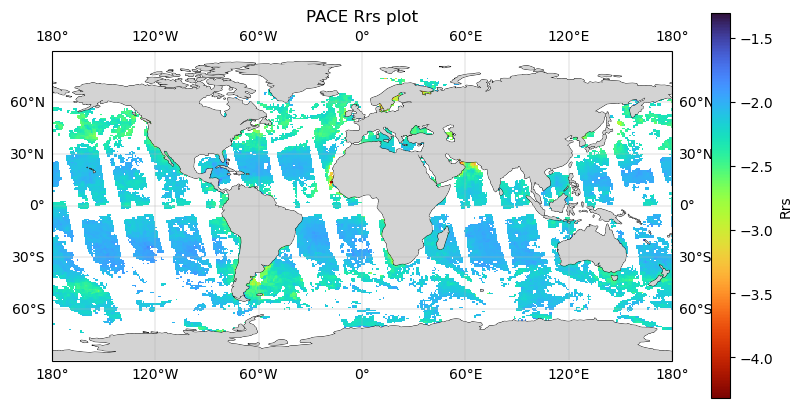

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

var_name = "Kd'

da_small = ds[var_name].isel(time=10, wavelength=50).coarsen(
    lat=8,
    lon=8,
    boundary="trim",
).mean().compute()

var = da_small

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

var.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="turbo_r",
    cbar_kwargs={"label": var_name},
)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.set_global()
ax.gridlines(draw_labels=True, linewidth=0.3)

plt.title(f"PACE {var_name} plot")
plt.show()

## Time series at a point

CPU times: user 29.2 s, sys: 2.19 s, total: 31.3 s
Wall time: 2min 54s


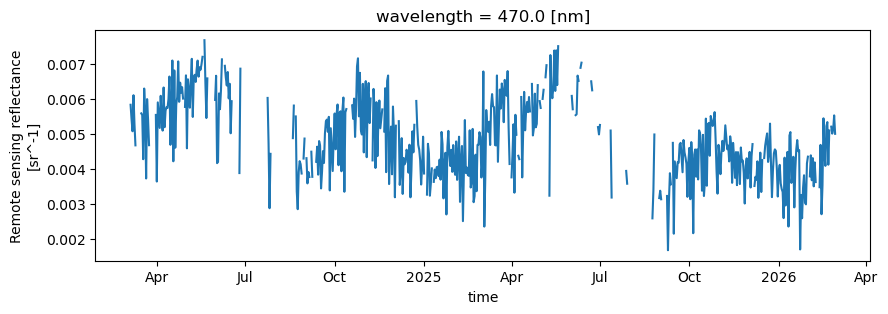

In [38]:
%%time
bbox = ds[var_name].isel(wavelength=50).sel(
    lon=slice(65, 75),
    lat=slice(20, 10),
)

ts = bbox.mean(("lat", "lon")).compute()

ts.plot(figsize=(10, 3));

## Monthly averages

In [ ]:
%%time
clim = (
    ds[var_name].isel(wavelength=50)
    .sel(lon=slice(65, 75), lat=slice(20, 10))
    .mean(("lat", "lon"))
    .groupby("time.month")
    .mean()
    .compute()
)

clim.plot(marker="o");

## Troubleshooting

How to get rid of stores or groups.

In [21]:
%%script false --no-raise
# Delete a whole store

import json
import boto3

# Icechunk repo location on Source Cooperative
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "fish-pace/pace-oci/inregion/PACE_OCI_L3M_KD"  # delete everything under this prefix

# Load temporary Source upload credentials
with open("source-creds.json") as f:
    source_creds = json.load(f)

icechunk_region = "us-west-2"

s3 = boto3.client(
    "s3",
    region_name=icechunk_region,
    aws_access_key_id=source_creds["aws_access_key_id"],
    aws_secret_access_key=source_creds["aws_secret_access_key"],
    aws_session_token=source_creds["aws_session_token"],
)

def delete_s3_prefix(bucket, prefix):
    prefix = prefix.strip("/") + "/"

    paginator = s3.get_paginator("list_objects_v2")
    total = 0

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        objects = [{"Key": obj["Key"]} for obj in page.get("Contents", [])]

        if objects:
            s3.delete_objects(
                Bucket=bucket,
                Delete={"Objects": objects},
            )
            total += len(objects)

    print(f"Deleted {total} objects from s3://{bucket}/{prefix}")

delete_s3_prefix(icechunk_bucket, icechunk_prefix)

Deleted 4486 objects from s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_RRS/


In [10]:
#%%script false --no-raise
# Delete groups

import json
import icechunk
import zarr

icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "fish-pace/pace-oci/inregion/PACE_OCI_L3M_KD"
icechunk_region = "us-west-2"

with open("source-creds.json") as f:
    source_creds = json.load(f)

storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=icechunk_region,
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

repo = icechunk.Repository.open(storage)
session = repo.writable_session(branch="main")

root = zarr.open_group(session.store, mode="a")

group_name = "daily/4km"

try:
    root[group_name]
    print(f"Deleting /{group_name}")
    del root[group_name]
except KeyError:
    print(f"Not found: /{group_name}")

snapshot_id = session.commit("Remove group")
print(snapshot_id)

Not found: /daily/4km


IcechunkError:   x session error: cannot commit, no changes made to the session (use `allow_empty=true` to commit anyway)
  | 
  | context:
  |    0: icechunk::session::commit_inner
  |            with Remove group max_concurrent_nodes=1 rewrite_manifests=false commit_method=NewCommit allow_empty=false
  |              at icechunk/src/session.rs:1657
  | 


In [65]:
import icechunk as ic

url_prefix = "s3://ob-cumulus-prod-public/"

repo = ic.Repository.open(storage)

config = repo.config
config.set_virtual_chunk_container(
    ic.VirtualChunkContainer(
        url_prefix=url_prefix,
        store=ic.s3_store(
            region="us-west-2",
            anonymous=False,
        ),
    )
)

repo.save_config()

In [18]:
# upload files
import json
import s3fs

icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "fish-pace/pace-oci"

with open("source-creds.json") as f:
    source_creds = json.load(f)

fs = s3fs.S3FileSystem(
    key=source_creds["aws_access_key_id"],
    secret=source_creds["aws_secret_access_key"],
    token=source_creds["aws_session_token"],
    client_kwargs={"region_name": "us-west-2"},
)

files_to_upload = [
    "README.md",
    "pace-icechunk-examples.ipynb",
    "pace-chl-icechunk-sc.ipynb",
    "pace-rrs-icechunk-sc.ipynb",
    "pace-kd-icechunk-sc.ipynb",
    "environment.yml",
]

for local_file in files_to_upload:
    dest = f"{icechunk_bucket}/{icechunk_prefix}/{local_file}"
    fs.put(local_file, dest)
    print(f"Uploaded {local_file} -> s3://{dest}")

Uploaded README.md -> s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/README.md
Uploaded pace-icechunk-examples.ipynb -> s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/pace-icechunk-examples.ipynb
Uploaded pace-chl-icechunk-sc.ipynb -> s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/pace-chl-icechunk-sc.ipynb
Uploaded pace-rrs-icechunk-sc.ipynb -> s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/pace-rrs-icechunk-sc.ipynb
Uploaded pace-kd-icechunk-sc.ipynb -> s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/pace-kd-icechunk-sc.ipynb
Uploaded environment.yml -> s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/environment.yml


In [9]:
# Remove files
import json
import s3fs

icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "fish-pace/pace-oci/inregion/PACE_OCI_L3M_CHL"

with open("source-creds.json") as f:
    source_creds = json.load(f)

fs = s3fs.S3FileSystem(
    key=source_creds["aws_access_key_id"],
    secret=source_creds["aws_secret_access_key"],
    token=source_creds["aws_session_token"],
    client_kwargs={"region_name": "us-west-2"},
)

files_to_remove = [
    "README.md",
    "pace-icechunk-examples.ipynb",
    "pace-chl-icechunk-sc.ipynb",
    "environment.yml",
]

for filename in files_to_remove:
    path = f"{icechunk_bucket}/{icechunk_prefix}/{filename}"
    if fs.exists(path):
        fs.rm(path)
        print(f"Removed s3://{path}")
    else:
        print(f"Not found: s3://{path}")

Removed s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_CHL/README.md
Removed s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_CHL/pace-icechunk-examples.ipynb
Removed s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_CHL/pace-chl-icechunk-sc.ipynb
Removed s3://us-west-2.opendata.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_CHL/environment.yml


## Check time stamps

In [19]:
import pandas as pd
import xarray as xr


def _as_datetime_index(time_values):
    """
    Convert ds.time.values to a pandas DatetimeIndex.
    Raises if conversion fails.
    """
    t = pd.to_datetime(time_values)
    return pd.DatetimeIndex(t)


def check_time_axis(time_values, cadence, name=""):
    """
    Check one time axis for duplicates, monotonic order, skips, short gaps,
    and missing expected timestamps/months.

    cadence: "daily", "8day", or "monthly"
    """

    t = _as_datetime_index(time_values)

    result = {
        "name": name,
        "cadence": cadence,
        "n": len(t),
        "start": t.min() if len(t) else pd.NaT,
        "end": t.max() if len(t) else pd.NaT,
        "has_nat": bool(t.isna().any()),
        "is_unique": bool(t.is_unique),
        "is_monotonic_increasing": bool(t.is_monotonic_increasing),
        "ok": True,
        "messages": [],
        "duplicates": pd.DatetimeIndex([]),
        "bad_gaps": None,
        "skips": None,
        "short_gaps": None,
        "missing": None,
        "off_grid": None,
    }

    if len(t) == 0:
        result["ok"] = False
        result["messages"].append("No time values.")
        return result

    if t.isna().any():
        result["ok"] = False
        result["messages"].append("NaT values found.")

    duplicates = t[t.duplicated(keep=False)]
    result["duplicates"] = duplicates

    if len(duplicates):
        result["ok"] = False
        result["messages"].append(f"{len(duplicates)} duplicate time entries found.")

    if not t.is_monotonic_increasing:
        result["ok"] = False
        result["messages"].append("Time is not monotonic increasing.")

    # Work on sorted unique values for missing/skip checks.
    tu = pd.DatetimeIndex(sorted(pd.unique(t.dropna())))

    if cadence in ("daily", "8day"):
        expected_delta = pd.Timedelta(days=1 if cadence == "daily" else 8)

        dt = t.to_series().diff().iloc[1:]

        bad_gaps = dt[dt != expected_delta]
        skips = dt[dt > expected_delta]
        short_gaps = dt[dt < expected_delta]

        result["bad_gaps"] = bad_gaps
        result["skips"] = skips
        result["short_gaps"] = short_gaps

        if len(bad_gaps):
            result["ok"] = False
            result["messages"].append(
                f"{len(bad_gaps)} non-{expected_delta} gaps found."
            )

        full = pd.date_range(tu[0], tu[-1], freq=expected_delta)
        missing = full.difference(tu)
        off_grid = tu.difference(full)

        result["missing"] = missing
        result["off_grid"] = off_grid

        if len(missing):
            result["ok"] = False
            result["messages"].append(f"{len(missing)} expected timestamps missing.")

        if len(off_grid):
            result["ok"] = False
            result["messages"].append(f"{len(off_grid)} timestamps are off the expected grid.")

    elif cadence == "monthly":
        # Monthly check by calendar month, not fixed day count.
        p = t.to_period("M")
        pu = pd.PeriodIndex(sorted(pd.unique(p.dropna())))

        month_steps = pd.Series(p.asi8, index=t).diff().iloc[1:]
        bad_gaps = month_steps[month_steps != 1]
        skips = month_steps[month_steps > 1]
        short_gaps = month_steps[month_steps < 1]

        result["bad_gaps"] = bad_gaps
        result["skips"] = skips
        result["short_gaps"] = short_gaps

        if len(bad_gaps):
            result["ok"] = False
            result["messages"].append(f"{len(bad_gaps)} non-1-month gaps found.")

        full_months = pd.period_range(pu[0], pu[-1], freq="M")
        missing_months = full_months.difference(pu)
        off_grid = pu.difference(full_months)

        result["missing"] = missing_months
        result["off_grid"] = off_grid

        if len(missing_months):
            result["ok"] = False
            result["messages"].append(f"{len(missing_months)} expected months missing.")

        # Optional extra monthly sanity check: all timestamps should use same day-of-month.
        day_counts = pd.Series(t.day).value_counts().sort_index()
        result["monthly_day_counts"] = day_counts

        if len(day_counts) > 1:
            result["ok"] = False
            result["messages"].append(
                f"Monthly timestamps use multiple day-of-month values: {list(day_counts.index)}"
            )

        duplicate_months = p[p.duplicated(keep=False)]
        result["duplicate_months"] = duplicate_months

        if len(duplicate_months):
            result["ok"] = False
            result["messages"].append(f"{len(duplicate_months)} duplicate month entries found.")

    else:
        raise ValueError("cadence must be 'daily', '8day', or 'monthly'")

    if result["ok"]:
        result["messages"].append("OK")

    return result


def print_time_check(result, max_items=20):
    """
    Human-readable report for one result from check_time_axis().
    """

    print("=" * 80)
    print(result["name"])
    print(f"cadence: {result['cadence']}")
    print(f"n:       {result['n']}")
    print(f"start:   {result['start']}")
    print(f"end:     {result['end']}")
    print(f"OK:      {result['ok']}")

    for msg in result["messages"]:
        print(f"- {msg}")

    if len(result["duplicates"]):
        print("\nDuplicates:")
        print(result["duplicates"][:max_items])

    if result["bad_gaps"] is not None and len(result["bad_gaps"]):
        print("\nBad gaps; index is the timestamp after the gap:")
        print(result["bad_gaps"].head(max_items))

    if result["skips"] is not None and len(result["skips"]):
        print("\nSkips; index is the timestamp after the skipped interval:")
        print(result["skips"].head(max_items))

    if result["short_gaps"] is not None and len(result["short_gaps"]):
        print("\nShort gaps / reversals / duplicates:")
        print(result["short_gaps"].head(max_items))

    if result["missing"] is not None and len(result["missing"]):
        print("\nMissing expected timestamps/months:")
        print(result["missing"][:max_items])

    if result["off_grid"] is not None and len(result["off_grid"]):
        print("\nOff-grid timestamps/months:")
        print(result["off_grid"][:max_items])

    if "monthly_day_counts" in result:
        print("\nMonthly day-of-month counts:")
        print(result["monthly_day_counts"])


def check_pace_time_groups(
    store,
    cadences=("daily", "monthly", "8Day"),
    grids=("0p1deg", "4km"),
    group_map=None,
    consolidated=False,
    max_items=20,
):
    """
    Check time axes for PACE Icechunk/Zarr groups.

    By default checks:
        Daily/0p1deg
        Daily/4km
        Monthly/0p1deg
        Monthly/4km
        8Day/0p1deg
        8Day/4km

    Returns:
        summary_df, results
    """

    if group_map is None:
        group_map = {
            "daily": "daily",
            "monthly": "monthly",
            "8Day": "8day",
        }

    results = []

    for cadence_group in cadences:
        cadence = group_map[cadence_group]

        for grid in grids:
            group = f"{cadence_group}/{grid}"

            try:
                ds = xr.open_zarr(
                    store,
                    consolidated=consolidated,
                    group=group,
                )

                if "time" not in ds.coords and "time" not in ds:
                    result = {
                        "name": group,
                        "cadence": cadence,
                        "n": None,
                        "start": None,
                        "end": None,
                        "has_nat": None,
                        "is_unique": None,
                        "is_monotonic_increasing": None,
                        "ok": False,
                        "messages": ["No time coordinate found."],
                        "duplicates": pd.DatetimeIndex([]),
                        "bad_gaps": None,
                        "skips": None,
                        "short_gaps": None,
                        "missing": None,
                        "off_grid": None,
                    }
                else:
                    result = check_time_axis(
                        ds.time.values,
                        cadence=cadence,
                        name=group,
                    )

            except Exception as e:
                result = {
                    "name": group,
                    "cadence": cadence,
                    "n": None,
                    "start": None,
                    "end": None,
                    "has_nat": None,
                    "is_unique": None,
                    "is_monotonic_increasing": None,
                    "ok": False,
                    "messages": [f"Failed to open/check group: {type(e).__name__}: {e}"],
                    "duplicates": pd.DatetimeIndex([]),
                    "bad_gaps": None,
                    "skips": None,
                    "short_gaps": None,
                    "missing": None,
                    "off_grid": None,
                }

            results.append(result)
            print_time_check(result, max_items=max_items)

    summary = []

    for r in results:
        summary.append(
            {
                "group": r["name"],
                "cadence": r["cadence"],
                "ok": r["ok"],
                "n": r["n"],
                "start": r["start"],
                "end": r["end"],
                "unique": r["is_unique"],
                "monotonic": r["is_monotonic_increasing"],
                "n_duplicates": len(r["duplicates"]) if r["duplicates"] is not None else None,
                "n_bad_gaps": len(r["bad_gaps"]) if r["bad_gaps"] is not None else None,
                "n_skips": len(r["skips"]) if r["skips"] is not None else None,
                "n_short_gaps": len(r["short_gaps"]) if r["short_gaps"] is not None else None,
                "n_missing": len(r["missing"]) if r["missing"] is not None else None,
                "messages": "; ".join(r["messages"]),
            }
        )

    summary_df = pd.DataFrame(summary)

    return summary_df, results

In [20]:
summary_df, results = check_pace_time_groups(store)

summary_df

daily/0p1deg
cadence: daily
n:       710
start:   2024-03-05 00:00:00
end:     2026-02-28 00:00:00
OK:      False
- 9 non-1 days 00:00:00 gaps found.
- 16 expected timestamps missing.

Bad gaps; index is the timestamp after the gap:
2024-03-15   3 days
2024-03-28   3 days
2024-05-30   6 days
2024-09-11   3 days
2024-10-18   2 days
2024-12-05   2 days
2025-01-03   2 days
2025-05-09   2 days
2026-02-11   2 days
dtype: timedelta64[ns]

Skips; index is the timestamp after the skipped interval:
2024-03-15   3 days
2024-03-28   3 days
2024-05-30   6 days
2024-09-11   3 days
2024-10-18   2 days
2024-12-05   2 days
2025-01-03   2 days
2025-05-09   2 days
2026-02-11   2 days
dtype: timedelta64[ns]

Missing expected timestamps/months:
DatetimeIndex(['2024-03-13', '2024-03-14', '2024-03-26', '2024-03-27',
               '2024-05-25', '2024-05-26', '2024-05-27', '2024-05-28',
               '2024-05-29', '2024-09-09', '2024-09-10', '2024-10-17',
               '2024-12-04', '2025-01-02', '2025-05-

,group,cadence,ok,n,start,end,unique,monotonic,n_duplicates,n_bad_gaps,n_skips,n_short_gaps,n_missing,messages
0,daily/0p1deg,daily,False,710,2024-03-05,2026-02-28,True,True,0,9,9,0,16,9 non-1 days 00:00:00 gaps found.; 16 expected...
1,daily/4km,daily,False,710,2024-03-05,2026-02-28,True,True,0,9,9,0,16,9 non-1 days 00:00:00 gaps found.; 16 expected...
2,monthly/0p1deg,monthly,True,23,2024-03-01,2026-01-01,True,True,0,0,0,0,0,OK
3,monthly/4km,monthly,True,23,2024-03-01,2026-01-01,True,True,0,0,0,0,0,OK
4,8Day/0p1deg,8day,False,91,2024-03-05,2026-02-18,True,True,0,2,0,2,52,2 non-8 days 00:00:00 gaps found.; 52 expected...
5,8Day/4km,8day,False,91,2024-03-05,2026-02-18,True,True,0,2,0,2,52,2 non-8 days 00:00:00 gaps found.; 52 expected...


## Fix config

In [31]:
import json
from pathlib import Path

creds_file = "source-creds.json"
with open(creds_file) as f:
    source_creds = json.load(f)
    
# This info you get from your storage
source_bucket = "us-west-2.opendata.source.coop"
source_prefix = "fish-pace/pace-oci/inregion/PACE_OCI_L3M_KD"
source_region = "us-west-2"

storage = icechunk.s3_storage(
    bucket=source_bucket,
    prefix=source_prefix,
    region=source_creds["region_name"],
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

url_prefix = "s3://ob-cumulus-prod-public/"

repo0 = ic.Repository.open(storage)

config = repo0.config
config.set_virtual_chunk_container(
    ic.VirtualChunkContainer(
        url_prefix=url_prefix,
        store=ic.s3_store(
            region="us-west-2",
            anonymous=False,
        ),
    )
)

# Important: open a repo instance WITH the modified config
repo1 = ic.Repository.open(storage, config=config)

# Save from the repo instance that actually has the modified config
repo1.save_config()

## Testing

In [29]:
import earthaccess
import icechunk as ic
import xarray as xr

url = "https://data.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_KD"

storage = ic.http_storage(url)

auth = earthaccess.login()
s3_credentials = auth.get_s3_credentials(daac="OBDAAC")

url_prefix = "s3://ob-cumulus-prod-public/"

virtual_creds = ic.credentials.containers_credentials({
    url_prefix: ic.credentials.s3_credentials(
        access_key_id=s3_credentials["accessKeyId"],
        secret_access_key=s3_credentials["secretAccessKey"],
        session_token=s3_credentials["sessionToken"],
    )
})

repo = ic.Repository.open(
    storage,
    config=config,
    authorize_virtual_chunk_access=virtual_creds,
)

store = repo.readonly_session("main").store

ds = xr.open_zarr(
    store,
    consolidated=False,
    group="daily/0p1deg",
)

test = ds["Rrs"].isel(time=10, wavelength=50).compute()

In [33]:
import icechunk as ic

url = "https://data.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_KD"
storage = ic.http_storage(url)

url_prefix = "s3://ob-cumulus-prod-public/"

# Open existing repo and get a COPY of its config
repo2 = ic.Repository.open(storage)
repo2.config

icechunk.config.RepositoryConfig(
    inline_chunk_threshold_bytes=None,
    get_partial_values_concurrency=None,
    max_concurrent_requests=None,
    num_updates_per_repo_info_file=None,
    compression=None,
    caching=None,
    storage=icechunk.storage.StorageSettings(
        unsafe_use_conditional_create=None,
        unsafe_use_conditional_update=None,
        unsafe_use_metadata=None,
        storage_class=None,
        metadata_storage_class=None,
        chunks_storage_class=None,
        minimum_size_for_multipart_upload=None,
        concurrency=None,
        retries=None,
        timeouts=None,
    ),
    manifest=None,
    repo_update_retries=None,
    virtual_chunk_containers={
        "s3://ob-cumulus-prod-public/": icechunk.virtual.VirtualChunkContainer(
            name=None,
            url_prefix="s3://ob-cumulus-prod-public/",
            store=icechunk.config.ObjectStoreConfig.S3(icechunk.storage.S3Options(
                region="us-west-2",
                endpoint_url=None,
                allow_http=False,
                anonymous=False,
                force_path_style=False,
                network_stream_timeout_seconds=60,
                requester_pays=False,
                checksum_algorithm=None,
            )),
        ),
    },
)